# Quantum Teleporation

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Qubit assignment:
* q0 = the input state $\ket{psi}$ to be teleported
* q1 = Alice's qubit from the shared Bell pair
* q2 = Bob's qubit from the shared Bell pair, which receives the teleported state

In [2]:
circuit = QuantumCircuit(3, 3)

## Step 1: Prepare the state to teleport on q0.
Here we choose |1> as a simple example input state.

In [3]:
circuit.x(0)

circuit.barrier()  # Barrier added only to separate stages visually.

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

## Step 1: Create a Bell pair between Alice (q1) and Bob (q2)

In [4]:
circuit.h(1)
circuit.cx(1, 2)
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

## Step 2: Alice performs the Bell-basis preparation step using the input qubit q0 and her entangled qubit q1

In [5]:
circuit.cx(0, 1)
circuit.h(0)

circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

## Step 3: Alice measures q0 and q1
The outcomes are stored in classical bits c0 and c1.

In [6]:
circuit.measure([0, 1], [0, 1])

circuit.barrier()  # Barrier added only to separate stages visually.

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

## Step 4: Bob applies correction operations to q2 based on Alice's measurement outcomes
In the standard teleportation protocol, these corrections correspond to classical feedforward of Alice's two bits.

In [7]:
circuit.cx(1, 2)
circuit.cz(0, 2)

## Step 5: Measure Bob's qubit to verify the teleported state.

In [8]:
circuit.measure([2], [2])

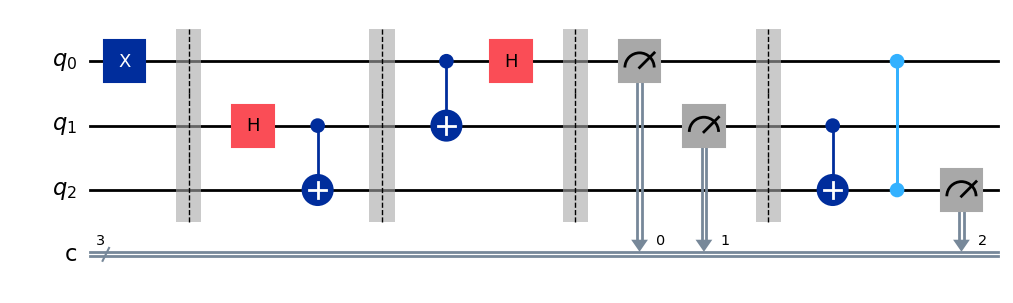

In [9]:
circuit.draw(output='mpl')

{'111': 255, '110': 271, '100': 246, '101': 252}


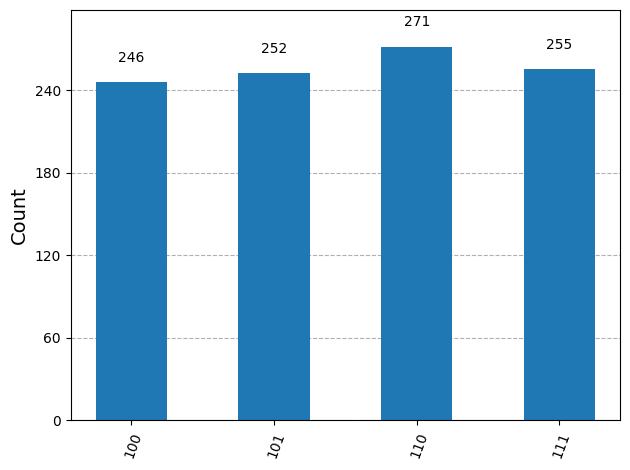

In [10]:
simulator = AerSimulator()

job = simulator.run(circuit, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)
plot_histogram(counts)